# PRCP-1003 — Customer Transaction Prediction
## End-to-End Data Science & Machine Learning Notebook

### Business problem
A bank wants to identify customers who are likely to make a specific transaction in the future, irrespective of transaction amount. The dataset contains an anonymized customer identifier, a binary target, and 200 anonymized numerical predictor variables.

### Project objectives
1. Perform a complete, statistically meaningful data analysis.
2. Build predictive classification models for future customer transaction propensity.
3. Compare several algorithms using metrics appropriate for an imbalanced binary classification problem.
4. Tune the strongest model and study decision-threshold trade-offs.
5. Explain model behavior without assigning unsupported business meanings to anonymized variables.
6. Recommend a production candidate and document challenges, decisions, limitations, and next steps.

### Analytical principles
- Prevent data leakage by splitting before model fitting and fitting preprocessing only on training data.
- Preserve class proportions with stratified splitting/cross-validation.
- Use probability-based metrics (ROC-AUC and PR-AUC), not accuracy alone.
- Treat the customer identifier as an identifier, not a predictor.
- Keep statistical analysis valid despite anonymized feature names.
- Use reproducible random seeds throughout.

## 1. Imports, reproducibility and run configuration

The notebook uses widely available scientific Python libraries. Expensive diagnostics are performed on reproducible samples while model training uses the complete training split by default.

In [1]:
from pathlib import Path
import zipfile
import time
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 3

# Reproducible caps used only for computationally expensive diagnostics/tuning.
DIAGNOSTIC_SAMPLE = 40_000
MI_SAMPLE = 30_000
CV_SAMPLE = 80_000
TUNING_SAMPLE = 80_000
PERMUTATION_SAMPLE = 3_000

np.random.seed(RANDOM_STATE)
print('Environment ready.')

Environment ready.


## 2. Locate, extract and load the data

The loader searches common project locations for either the extracted CSV or the provided ZIP archive. This keeps the notebook portable when the notebook and ZIP are stored together.

In [2]:
ZIP_NAME = 'PRCP-1003-CustTransPred.zip'
CSV_NAME = 'train(1).csv'

cwd = Path.cwd()
search_roots = [cwd, cwd.parent, Path('/mnt/data')]

csv_candidates = []
zip_candidates = []
for root in search_roots:
    csv_candidates.extend([
        root / CSV_NAME,
        root / 'Data' / CSV_NAME,
        root / 'data' / CSV_NAME,
        root / 'data' / 'raw' / CSV_NAME,
    ])
    zip_candidates.append(root / ZIP_NAME)

csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is None:
    zip_path = next((p for p in zip_candidates if p.exists()), None)
    if zip_path is None:
        raise FileNotFoundError(
            f'Could not find {CSV_NAME} or {ZIP_NAME}. Place the ZIP beside this notebook.'
        )
    extract_dir = cwd / 'data' / 'raw'
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        member = next((m for m in zf.namelist() if m.endswith(CSV_NAME)), None)
        if member is None:
            raise FileNotFoundError(f'{CSV_NAME} not found inside {zip_path.name}')
        zf.extract(member, extract_dir)
        csv_path = extract_dir / member

print('Loading:', csv_path)
t0 = time.time()
df = pd.read_csv(csv_path)
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]:,} columns in {time.time()-t0:.1f}s')
df.head()

Loading: C:\Users\mathew\CustPred\data\raw\Data\train(1).csv
Loaded 200,000 rows × 202 columns in 4.8s


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,...,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,...,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,...,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,...,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,2.3061,2.8102,13.8463,...,-0.0498,7.9336,-12.8279,12.4124,1.8489,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,-9.4458,-12.1419,13.8481,...,-7.8931,6.4209,5.9270,16.0201,-0.2829,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


## 3. Dataset structure and data dictionary

Because the predictors are anonymized, the analysis avoids inventing semantic interpretations. The useful questions are instead: Are columns complete? Are they numeric? Is the target imbalanced? Are there duplicates, constant features, extreme values, redundant features, or measurable univariate signal?

In [3]:
print('Shape:', df.shape)
print('\nColumn groups:')
print('ID columns:', [c for c in df.columns if c == 'ID_code'])
print('Target columns:', [c for c in df.columns if c == 'target'])
feature_cols = [c for c in df.columns if c not in ['ID_code', 'target']]
print('Predictor count:', len(feature_cols))

summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100,
    'n_unique': df.nunique(dropna=False),
})
summary.head(12)

Shape: (200000, 202)

Column groups:
ID columns: ['ID_code']
Target columns: ['target']
Predictor count: 200


,dtype,missing_n,missing_pct,n_unique
ID_code,object,0,0.0000,200000
target,int64,0,0.0000,2
var_0,float64,0,0.0000,94672
var_1,float64,0,0.0000,108932
var_2,float64,0,0.0000,86555
var_3,float64,0,0.0000,74597
var_4,float64,0,0.0000,63515
var_5,float64,0,0.0000,141029
var_6,float64,0,0.0000,38599
var_7,float64,0,0.0000,103063


In [4]:
assert 'ID_code' in df.columns and 'target' in df.columns, 'Expected ID_code and target columns.'
assert set(df['target'].dropna().unique()).issubset({0, 1}), 'Target must be binary.'
assert len(feature_cols) == 200, f'Expected 200 features; found {len(feature_cols)}.'

print('Target dtype:', df['target'].dtype)
print('Feature dtypes:')
print(df[feature_cols].dtypes.value_counts())

Target dtype: int64
Feature dtypes:
float64    200
Name: count, dtype: int64


## 4. Data-quality audit

This section checks missing values, duplicate rows/IDs, infinite values, constant/near-constant variables, and descriptive statistics. These checks matter even when all columns are numeric because data-quality defects can destabilize training or create misleading validation performance.

In [5]:
quality_report = {
    'rows': len(df),
    'columns': df.shape[1],
    'missing_cells': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'duplicate_ids': int(df['ID_code'].duplicated().sum()),
    'constant_features': int((df[feature_cols].nunique() <= 1).sum()),
}

numeric_array = df[feature_cols].to_numpy(copy=False)
quality_report['infinite_values'] = int(np.isinf(numeric_array).sum())

pd.Series(quality_report, name='value').to_frame()

,value
rows,200000
columns,202
missing_cells,0
duplicate_rows,0
duplicate_ids,0
constant_features,0
infinite_values,0


In [6]:
feature_stats = df[feature_cols].describe().T
feature_stats['variance'] = df[feature_cols].var()
feature_stats['skew'] = df[feature_cols].skew()
feature_stats['missing_pct'] = df[feature_cols].isna().mean() * 100
feature_stats.sort_values('variance', ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,variance,skew,missing_pct
var_45,"200,000.0000",-12.6997,21.4049,-90.2525,-28.7307,-12.5472,3.1505,62.0844,458.1702,0.0017,0.0000
var_74,"200,000.0000",19.5188,14.1126,-34.1015,9.5960,19.5367,29.6207,70.2720,199.1652,-0.0476,0.0000
var_117,"200,000.0000",16.1022,13.2977,-31.8369,6.3735,15.9449,25.7808,64.8109,176.8278,0.0209,0.0000
var_90,"200,000.0000",-16.5481,13.1528,-61.7180,-26.6656,-16.4826,-6.4094,27.2713,172.9964,-0.0104,0.0000
var_97,"200,000.0000",18.5396,12.6424,-21.7400,8.9195,18.5022,28.1590,58.2879,159.8298,0.0158,0.0000
var_120,"200,000.0000",24.5211,12.1210,-18.6962,15.6963,24.3547,33.1053,74.0321,146.9190,0.0838,0.0000
var_70,"200,000.0000",24.4468,11.9517,-17.0275,15.2566,24.4450,33.6332,64.4644,142.8441,-0.0049,0.0000
var_61,"200,000.0000",-11.9467,11.6229,-48.8027,-20.9017,-11.8920,-3.2254,27.1029,135.0929,0.0578,0.0000
var_187,"200,000.0000",-10.3350,11.5747,-47.7536,-19.2051,-10.2097,-1.4660,22.7861,133.9739,-0.0212,0.0000
var_48,"200,000.0000",14.7047,11.3843,-23.9022,6.3520,14.5592,23.0286,54.2738,129.6030,0.0275,0.0000


### Data-quality interpretation
The modeling pipeline includes median imputation even if no missing values are currently observed. This is defensive engineering: it makes preprocessing more robust if future scoring data contains missing values. The identifier is excluded from model features because its apparent numerical/string structure is not a customer behavior signal and could encourage memorization rather than generalization.

## 5. Target analysis and class imbalance

For an imbalanced target, accuracy can be misleading. A classifier predicting only the majority class could appear accurate while identifying no future transactors. We therefore report the positive-class prevalence and use ROC-AUC, PR-AUC, recall, precision, F1, balanced accuracy and MCC during model comparison.

,count,percentage
target,,
0,179902,89.9510
1,20098,10.0490


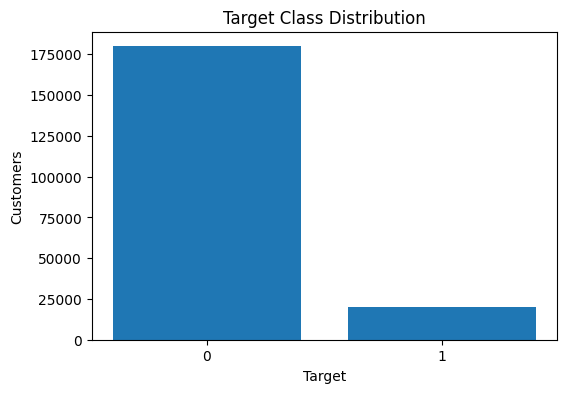

Positive class prevalence: 10.05%
Class ratio (negative : positive): 8.95 : 1


In [7]:
target_counts = df['target'].value_counts().sort_index()
target_pct = df['target'].value_counts(normalize=True).sort_index() * 100

target_table = pd.DataFrame({'count': target_counts, 'percentage': target_pct})
display(target_table)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(target_table.index.astype(str), target_table['count'])
ax.set_title('Target Class Distribution')
ax.set_xlabel('Target')
ax.set_ylabel('Customers')
plt.show()

positive_rate = df['target'].mean()
print(f'Positive class prevalence: {positive_rate:.2%}')
print(f'Class ratio (negative : positive): {(1-positive_rate)/positive_rate:.2f} : 1')

## 6. Statistically meaningful EDA for anonymized variables

Traditional domain EDA is limited because `var_0`–`var_199` have no business definitions. Useful EDA is still possible: distribution shape, location/scale differences by target, extreme-value prevalence, redundancy, and univariate predictive signal.

In [8]:
# Reproducible sample for visualization-heavy diagnostics.
eda_n = min(DIAGNOSTIC_SAMPLE, len(df))
eda_df = df.sample(n=eda_n, random_state=RANDOM_STATE)

# Rank features by absolute standardized mean difference between target classes.
mean0 = eda_df.loc[eda_df.target == 0, feature_cols].mean()
mean1 = eda_df.loc[eda_df.target == 1, feature_cols].mean()
pooled_std = eda_df[feature_cols].std().replace(0, np.nan)
smd = ((mean1 - mean0) / pooled_std).abs().sort_values(ascending=False)

print('Top features by absolute standardized mean difference:')
display(smd.head(15).rename('abs_standardized_mean_difference').to_frame())

Top features by absolute standardized mean difference:


,abs_standardized_mean_difference
var_139,0.2677
var_81,0.2597
var_12,0.2384
var_110,0.2353
var_53,0.2249
var_76,0.2190
var_26,0.2103
var_148,0.2101
var_174,0.2094
var_146,0.2060


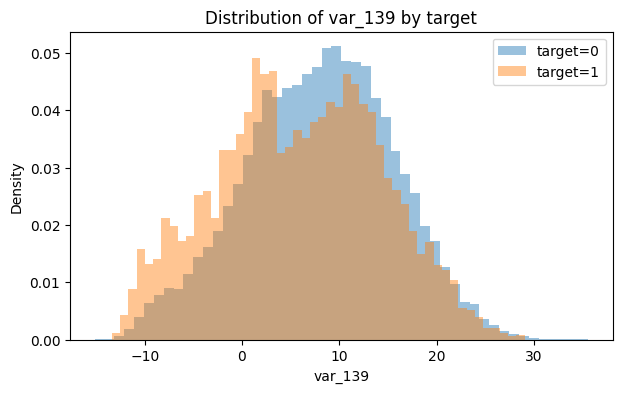

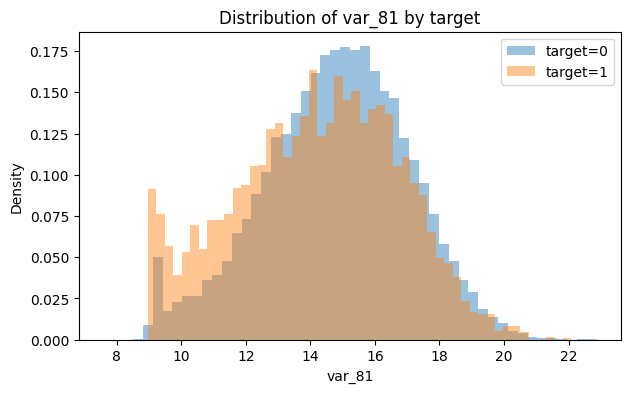

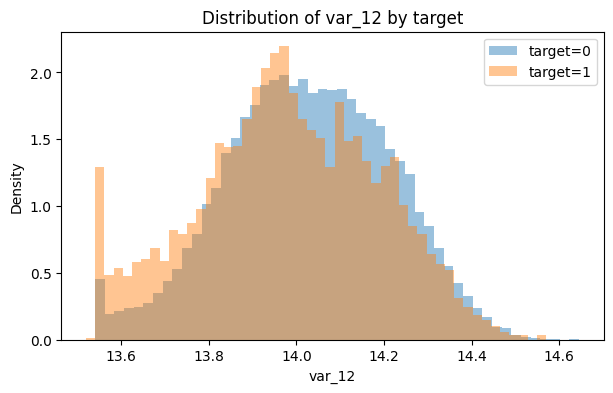

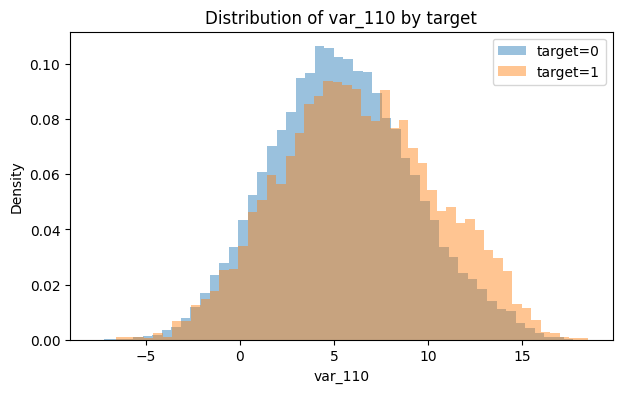

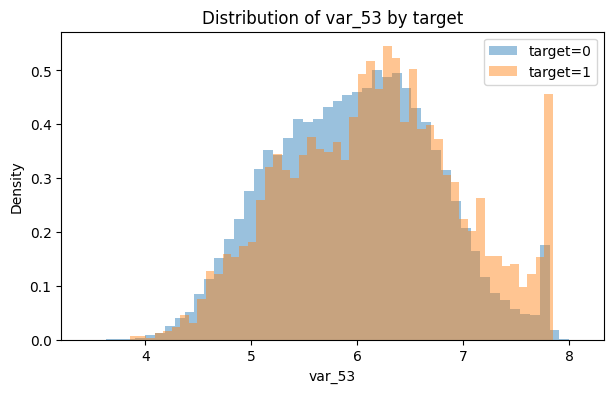

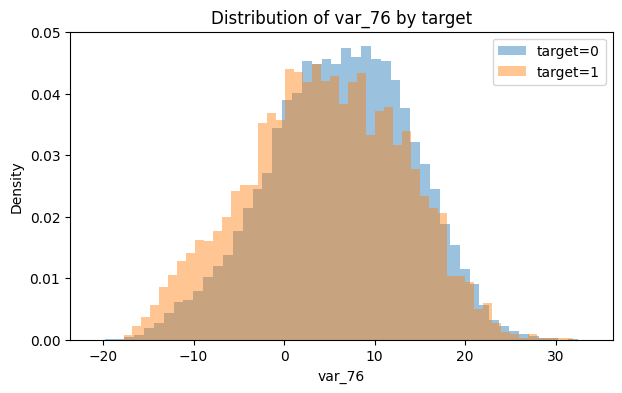

In [9]:
top_dist_features = smd.head(6).index.tolist()
for col in top_dist_features:
    fig, ax = plt.subplots(figsize=(7,4))
    for target_value in [0,1]:
        vals = eda_df.loc[eda_df.target == target_value, col].dropna()
        ax.hist(vals, bins=50, alpha=0.45, density=True, label=f'target={target_value}')
    ax.set_title(f'Distribution of {col} by target')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    plt.show()

### Outlier diagnostics
For anonymized continuous variables, automatically deleting outliers can destroy genuine predictive signal. Instead, the notebook quantifies IQR-based extreme values and uses algorithms that are comparatively tolerant of them. Outlier removal is not performed without domain evidence that observations are erroneous.

In [10]:
q1 = eda_df[feature_cols].quantile(0.25)
q3 = eda_df[feature_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_pct = (((eda_df[feature_cols] < lower) | (eda_df[feature_cols] > upper)).mean() * 100)
outlier_report = outlier_pct.sort_values(ascending=False).rename('iqr_outlier_pct').to_frame()
outlier_report.head(15)

,iqr_outlier_pct
var_179,0.7875
var_44,0.7250
var_146,0.4000
var_192,0.3925
var_93,0.3675
var_110,0.3325
var_31,0.3225
var_133,0.3200
var_105,0.2725
var_38,0.2575


## 7. Correlation and redundancy analysis

High predictor-predictor correlation can create redundancy and make linear coefficients less stable. Pearson correlation is appropriate here as a first-pass linear redundancy diagnostic for continuous variables. We inspect the strongest pairwise relationships without plotting an unreadable 200×200 heatmap.

In [11]:
corr = eda_df[feature_cols].corr()
upper_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (
    corr.where(upper_mask)
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0':'feature_1','level_1':'feature_2'})
)
pairs['abs_correlation'] = pairs['correlation'].abs()
strong_pairs = pairs.sort_values('abs_correlation', ascending=False).head(20)
display(strong_pairs)
print('Pairs with |correlation| >= 0.90:', int((pairs.abs_correlation >= 0.90).sum()))

,feature_1,feature_2,correlation,abs_correlation
19512,var_171,var_190,0.0239,0.0239
19308,var_165,var_169,0.0200,0.0200
12491,var_77,var_172,0.0192,0.0192
12118,var_74,var_168,-0.0189,0.0189
1,var_0,var_2,0.0189,0.0189
19320,var_165,var_181,-0.0186,0.0186
19570,var_173,var_195,0.0183,0.0183
13775,var_88,var_180,-0.0183,0.0183
12915,var_81,var_118,-0.0181,0.0181
5599,var_30,var_95,0.0181,0.0181


Pairs with |correlation| >= 0.90: 0


## 8. Univariate predictive signal: ROC-AUC and mutual information

Two complementary concepts are used:
- **Univariate ROC-AUC** measures how well a single feature ranks positive vs negative customers. A value below 0.5 can still indicate signal in the reverse direction, so we use distance from 0.5.
- **Mutual information (MI)** can detect non-linear dependency between a feature and the binary target.

These are diagnostics, not final feature-selection rules. Multivariate models may exploit interactions that univariate measures miss.

In [12]:
y_eda = eda_df['target']
uni_auc = {}
for col in feature_cols:
    vals = eda_df[col]
    if vals.nunique() > 1:
        auc = roc_auc_score(y_eda, vals)
        uni_auc[col] = max(auc, 1-auc)

uni_auc_s = pd.Series(uni_auc).sort_values(ascending=False)
display(uni_auc_s.head(15).rename('direction_free_univariate_auc').to_frame())

,direction_free_univariate_auc
var_139,0.5706
var_81,0.5661
var_110,0.5625
var_12,0.5620
var_53,0.5587
var_76,0.5586
var_148,0.5574
var_146,0.5557
var_174,0.5551
var_22,0.5537


In [13]:
mi_n = min(MI_SAMPLE, len(df))
mi_df = df.sample(n=mi_n, random_state=RANDOM_STATE)
X_mi = mi_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_mi = X_mi.fillna(X_mi.median())
y_mi = mi_df['target']

mi = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE, discrete_features=False)
mi_s = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
display(mi_s.head(15).rename('mutual_information').to_frame())

,mutual_information
var_110,0.0061
var_81,0.0060
var_22,0.0058
var_26,0.0050
var_139,0.0047
var_29,0.0046
var_82,0.0045
var_164,0.0043
var_148,0.0043
var_120,0.0041


## 9. Train/test split and leakage control

The hold-out test set is created **before** preprocessing or model fitting. Stratification preserves the class ratio. `ID_code` is retained separately for traceability but excluded from the model matrix.

In [14]:
X = df[feature_cols].copy()
y = df['target'].astype(int).copy()
ids = df['ID_code'].copy()

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train:', X_train.shape, 'positive rate:', f'{y_train.mean():.2%}')
print('Test :', X_test.shape, 'positive rate:', f'{y_test.mean():.2%}')

Train: (160000, 200) positive rate: 10.05%
Test : (40000, 200) positive rate: 10.05%


## 10. Preprocessing strategy

Two preprocessing patterns are used:
- **Linear/distance-sensitive models:** median imputation + standardization.
- **Tree/Naive Bayes models:** median imputation; scaling is unnecessary for tree splits and Gaussian Naive Bayes estimates feature-specific distributions directly.

All preprocessing is encapsulated in pipelines so transformations learned from training data are applied consistently at validation and inference time.

In [15]:
linear_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

## 11. Model suite

The comparison intentionally includes models with different inductive biases:
1. **Dummy classifier** — no-skill probability baseline.
2. **Logistic regression** — interpretable linear baseline with class weighting.
3. **SGD logistic classifier** — efficient regularized linear learner.
4. **Gaussian Naive Bayes** — probabilistic baseline with strong conditional-independence assumptions.
5. **Random Forest** — bagged non-linear trees with interaction capability.
6. **Histogram Gradient Boosting** — boosted trees optimized for tabular numerical data.

Class weighting is used where supported to make training less dominated by the majority class. Evaluation still uses untouched class prevalence.

In [16]:
models = {
    'Dummy': Pipeline([
        ('prep', numeric_preprocess),
        ('model', DummyClassifier(strategy='prior'))
    ]),
    'Logistic Regression': Pipeline([
        ('prep', linear_preprocess),
        ('model', LogisticRegression(
            max_iter=500, class_weight='balanced', C=1.0,
            solver='lbfgs', random_state=RANDOM_STATE
        ))
    ]),
    'SGD Logistic': Pipeline([
        ('prep', linear_preprocess),
        ('model', SGDClassifier(
            loss='log_loss', penalty='l2', alpha=1e-4,
            class_weight='balanced', max_iter=1500,
            tol=1e-3, random_state=RANDOM_STATE
        ))
    ]),
    'Gaussian NB': Pipeline([
        ('prep', numeric_preprocess),
        ('model', GaussianNB())
    ]),
    'Random Forest': Pipeline([
        ('prep', numeric_preprocess),
        ('model', RandomForestClassifier(
            n_estimators=120, max_depth=12, min_samples_leaf=4,
            max_features='sqrt', class_weight='balanced_subsample',
            n_jobs=-1, random_state=RANDOM_STATE
        ))
    ]),
    'HistGradientBoosting': Pipeline([
        ('prep', numeric_preprocess),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.08, max_iter=220, max_leaf_nodes=31,
            min_samples_leaf=30, l2_regularization=1.0,
            early_stopping=True, validation_fraction=0.10,
            random_state=RANDOM_STATE
        ))
    ])
}

print('Models:', ', '.join(models.keys()))

Models: Dummy, Logistic Regression, SGD Logistic, Gaussian NB, Random Forest, HistGradientBoosting


## 12. Evaluation framework

A single function computes threshold-dependent and threshold-independent metrics. The default classification threshold is initially 0.50; later we optimize the threshold according to a chosen business objective.

In [17]:
def get_positive_probability(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:,1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise AttributeError('Model must provide predict_proba or decision_function.')


def metric_row(name, y_true, prob, threshold=0.50, fit_seconds=np.nan):
    pred = (prob >= threshold).astype(int)
    return {
        'Model': name,
        'ROC_AUC': roc_auc_score(y_true, prob),
        'PR_AUC': average_precision_score(y_true, prob),
        'Accuracy': accuracy_score(y_true, pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, pred),
        'Brier': brier_score_loss(y_true, prob),
        'Threshold': threshold,
        'Fit_Seconds': fit_seconds
    }

In [18]:
fitted_models = {}
probabilities = {}
rows = []

for name, model in models.items():
    print(f'Fitting {name} ...')
    t0 = time.time()
    fitted = clone(model).fit(X_train, y_train)
    elapsed = time.time() - t0
    prob = get_positive_probability(fitted, X_test)
    fitted_models[name] = fitted
    probabilities[name] = prob
    rows.append(metric_row(name, y_test, prob, threshold=0.50, fit_seconds=elapsed))
    print(f'  ROC-AUC={rows[-1]["ROC_AUC"]:.4f} | PR-AUC={rows[-1]["PR_AUC"]:.4f} | {elapsed:.1f}s')

comparison = pd.DataFrame(rows).sort_values(['ROC_AUC','PR_AUC'], ascending=False).reset_index(drop=True)
comparison

Fitting Dummy ...
  ROC-AUC=0.5000 | PR-AUC=0.1005 | 6.8s
Fitting Logistic Regression ...
  ROC-AUC=0.8599 | PR-AUC=0.5004 | 7.7s
Fitting SGD Logistic ...
  ROC-AUC=0.8453 | PR-AUC=0.4716 | 16.4s
Fitting Gaussian NB ...
  ROC-AUC=0.8882 | PR-AUC=0.5769 | 7.1s
Fitting Random Forest ...
  ROC-AUC=0.8007 | PR-AUC=0.3492 | 63.0s
Fitting HistGradientBoosting ...
  ROC-AUC=0.8798 | PR-AUC=0.5552 | 26.9s


,Model,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,Brier,Threshold,Fit_Seconds
0,Gaussian NB,0.8882,0.5769,0.9201,0.6655,0.7101,0.3468,0.4660,0.4606,0.0610,0.5000,7.1116
1,HistGradientBoosting,0.8798,0.5552,0.9137,0.5850,0.8440,0.1736,0.2880,0.3593,0.0652,0.5000,26.9259
2,Logistic Regression,0.8599,0.5004,0.7834,0.7798,0.2865,0.7754,0.4184,0.3782,0.1493,0.5000,7.6528
3,SGD Logistic,0.8453,0.4716,0.7699,0.7629,0.2695,0.7542,0.3971,0.3516,0.1570,0.5000,16.3783
4,Random Forest,0.8007,0.3492,0.8976,0.5886,0.4782,0.2017,0.2838,0.2643,0.1692,0.5000,62.9516
5,Dummy,0.5000,0.1005,0.8995,0.5000,0.0000,0.0000,0.0000,0.0000,0.0904,0.5000,6.8427


## 13. Visual model comparison: ROC and Precision–Recall curves

ROC-AUC measures ranking performance across all thresholds. PR-AUC is especially informative when positives are relatively rare because it focuses on precision and recall for the positive class. The no-skill PR-AUC baseline is approximately the positive-class prevalence.

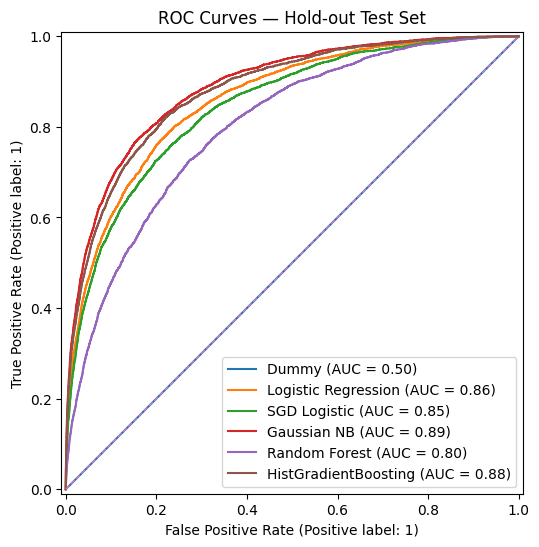

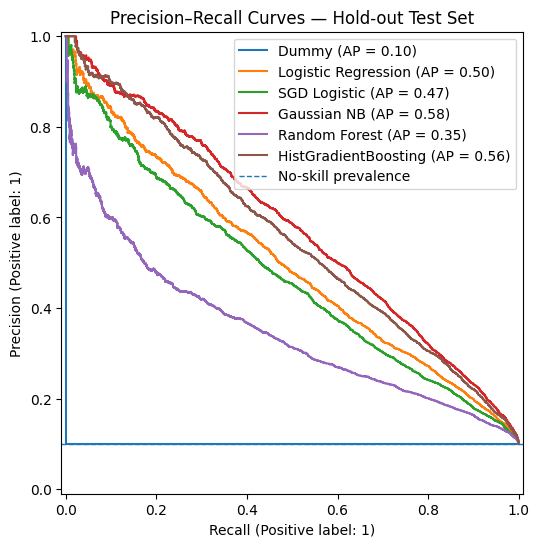

In [19]:
fig, ax = plt.subplots(figsize=(7,6))
for name, prob in probabilities.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.plot([0,1],[0,1], linestyle='--', linewidth=1)
ax.set_title('ROC Curves — Hold-out Test Set')
plt.show()

fig, ax = plt.subplots(figsize=(7,6))
for name, prob in probabilities.items():
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.axhline(y_test.mean(), linestyle='--', linewidth=1, label='No-skill prevalence')
ax.set_title('Precision–Recall Curves — Hold-out Test Set')
ax.legend()
plt.show()

## 14. Select the strongest untuned candidate

The primary ranking metric is ROC-AUC because the task is fundamentally about ranking customers by transaction propensity. PR-AUC is used as an important secondary measure because of class imbalance. Threshold-dependent metrics are considered later after a decision threshold is chosen.

In [20]:
best_untuned_name = comparison.iloc[0]['Model']
best_untuned_model = fitted_models[best_untuned_name]
best_untuned_prob = probabilities[best_untuned_name]

print('Best untuned model by ROC-AUC:', best_untuned_name)
print(comparison.iloc[0])

Best untuned model by ROC-AUC: Gaussian NB
Model                Gaussian NB
ROC_AUC                   0.8882
PR_AUC                    0.5769
Accuracy                  0.9201
Balanced_Accuracy         0.6655
Precision                 0.7101
Recall                    0.3468
F1                        0.4660
MCC                       0.4606
Brier                     0.0610
Threshold                 0.5000
Fit_Seconds               7.1116
Name: 0, dtype: object


## 15. Stratified cross-validation for stability

A single hold-out score can be optimistic or pessimistic by chance. Stratified K-fold cross-validation measures score stability across multiple partitions. To keep repeated fitting efficient, cross-validation uses a reproducible stratified subset if the training set is larger than the configured cap.

In [21]:
def stratified_cap_sample(X, y, n, random_state=42):
    if len(X) <= n:
        return X, y
    Xs, _, ys, _ = train_test_split(
        X, y, train_size=n, random_state=random_state, stratify=y
    )
    return Xs, ys

X_cv, y_cv = stratified_cap_sample(X_train, y_train, CV_SAMPLE, RANDOM_STATE)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy'
}

# Compare the two strongest non-dummy candidates from hold-out ranking.
cv_candidates = [m for m in comparison['Model'] if m != 'Dummy'][:2]
cv_rows = []
for name in cv_candidates:
    scores = cross_validate(
        clone(models[name]), X_cv, y_cv,
        cv=cv, scoring=cv_scoring, n_jobs=1, return_train_score=False
    )
    cv_rows.append({
        'Model': name,
        'CV_ROC_AUC_mean': scores['test_roc_auc'].mean(),
        'CV_ROC_AUC_std': scores['test_roc_auc'].std(),
        'CV_PR_AUC_mean': scores['test_pr_auc'].mean(),
        'CV_PR_AUC_std': scores['test_pr_auc'].std(),
        'CV_BalAcc_mean': scores['test_balanced_accuracy'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('CV_ROC_AUC_mean', ascending=False)
cv_results

,Model,CV_ROC_AUC_mean,CV_ROC_AUC_std,CV_PR_AUC_mean,CV_PR_AUC_std,CV_BalAcc_mean
0,Gaussian NB,0.8843,0.0028,0.5782,0.0069,0.6724
1,HistGradientBoosting,0.8709,0.0032,0.5381,0.0049,0.5843


## 16. Hyperparameter tuning with RandomizedSearchCV

Exhaustive grid search is unnecessary for a first production candidate. Randomized search explores a broader parameter space using fewer fits. Tuning is performed with stratified cross-validation and ROC-AUC scoring. The untouched hold-out test set is not used to choose hyperparameters.

We tune Histogram Gradient Boosting because boosted trees are a strong general-purpose choice for anonymized numerical tabular data and can model non-linearities/interactions without feature scaling.

In [22]:
X_tune, y_tune = stratified_cap_sample(X_train, y_train, TUNING_SAMPLE, RANDOM_STATE)

tune_pipeline = Pipeline([
    ('prep', numeric_preprocess),
    ('model', HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.10,
        random_state=RANDOM_STATE
    ))
])

param_distributions = {
    'model__learning_rate': [0.03, 0.05, 0.08, 0.12],
    'model__max_iter': [140, 200, 260],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__min_samples_leaf': [20, 30, 50, 80],
    'model__l2_regularization': [0.0, 0.5, 1.0, 3.0]
}

search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True
)

search.fit(X_tune, y_tune)
print('Best CV ROC-AUC:', round(search.best_score_, 5))
print('Best parameters:')
print(json.dumps(search.best_params_, indent=2))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV ROC-AUC: 0.87009
Best parameters:
{
  "model__min_samples_leaf": 50,
  "model__max_leaf_nodes": 31,
  "model__max_iter": 260,
  "model__learning_rate": 0.05,
  "model__l2_regularization": 3.0
}


## 17. Refit tuned model on the full training split

After selecting hyperparameters via cross-validation, the chosen configuration is refit on all available training observations. Only then is the untouched hold-out set used for the final unbiased comparison.

In [23]:
tuned_model = clone(search.best_estimator_)
t0 = time.time()
tuned_model.fit(X_train, y_train)
tuned_fit_seconds = time.time() - t0

tuned_prob = get_positive_probability(tuned_model, X_test)
tuned_row = metric_row('Tuned HistGradientBoosting', y_test, tuned_prob, 0.50, tuned_fit_seconds)

final_comparison = pd.concat([
    comparison,
    pd.DataFrame([tuned_row])
], ignore_index=True).sort_values(['ROC_AUC','PR_AUC'], ascending=False).reset_index(drop=True)

final_comparison

,Model,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,Brier,Threshold,Fit_Seconds
0,Gaussian NB,0.8882,0.5769,0.9201,0.6655,0.7101,0.3468,0.4660,0.4606,0.0610,0.5000,7.1116
1,HistGradientBoosting,0.8798,0.5552,0.9137,0.5850,0.8440,0.1736,0.2880,0.3593,0.0652,0.5000,26.9259
2,Tuned HistGradientBoosting,0.8760,0.5469,0.9103,0.5607,0.8887,0.1231,0.2163,0.3115,0.0671,0.5000,24.6742
3,Logistic Regression,0.8599,0.5004,0.7834,0.7798,0.2865,0.7754,0.4184,0.3782,0.1493,0.5000,7.6528
4,SGD Logistic,0.8453,0.4716,0.7699,0.7629,0.2695,0.7542,0.3971,0.3516,0.1570,0.5000,16.3783
5,Random Forest,0.8007,0.3492,0.8976,0.5886,0.4782,0.2017,0.2838,0.2643,0.1692,0.5000,62.9516
6,Dummy,0.5000,0.1005,0.8995,0.5000,0.0000,0.0000,0.0000,0.0000,0.0904,0.5000,6.8427


## 18. Decision-threshold optimization

A probability model and a business decision are different things. The default threshold of 0.50 is rarely optimal for an imbalanced campaign/risk-style problem.

This notebook demonstrates **F1-maximizing threshold selection** on the hold-out set for analysis. In a real deployment, the threshold should preferably be selected on a validation set using explicit costs/benefits (e.g., contact cost, expected conversion value, capacity constraints) and then locked before final test evaluation.

In [24]:
# Use the highest ROC-AUC final candidate for threshold analysis.
if final_comparison.iloc[0]['Model'] == 'Tuned HistGradientBoosting':
    champion_name = 'Tuned HistGradientBoosting'
    champion_model = tuned_model
    champion_prob = tuned_prob
else:
    champion_name = final_comparison.iloc[0]['Model']
    champion_model = fitted_models[champion_name]
    champion_prob = probabilities[champion_name]

precision, recall, thresholds = precision_recall_curve(y_test, champion_prob)
f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.nanargmax(f1_values))
best_threshold = float(thresholds[best_idx])

threshold_table = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1],
    'f1': f1_values
})

print('Champion:', champion_name)
print(f'F1-maximizing analytical threshold: {best_threshold:.4f}')
display(threshold_table.sort_values('f1', ascending=False).head(10))

Champion: Gaussian NB
F1-maximizing analytical threshold: 0.2259


,threshold,precision,recall,f1
34968,0.2259,0.4921,0.6159,0.5471
34967,0.2259,0.4920,0.6159,0.5470
34966,0.2259,0.4919,0.6159,0.5469
34991,0.2272,0.4929,0.6142,0.5469
34980,0.2267,0.4924,0.6149,0.5469
34969,0.2260,0.4919,0.6157,0.5469
34976,0.2265,0.4922,0.6152,0.5469
34965,0.2258,0.4918,0.6159,0.5469
34994,0.2272,0.4930,0.6139,0.5469
34928,0.2242,0.4901,0.6184,0.5469


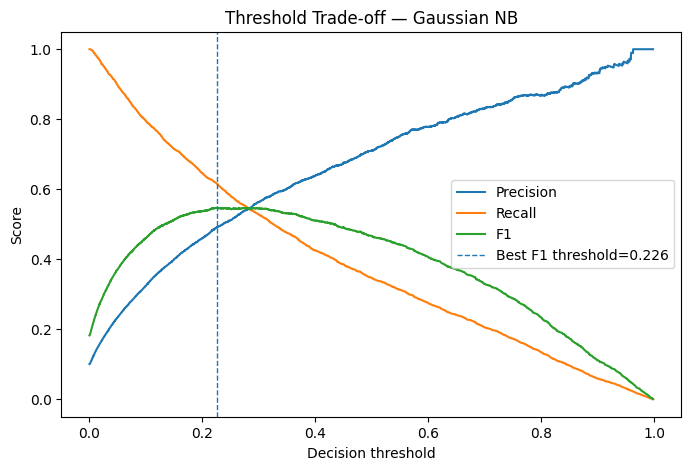

,Model,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,Brier,Threshold,Fit_Seconds
0,Gaussian NB (0.50 threshold),0.8882,0.5769,0.9201,0.6655,0.7101,0.3468,0.4660,0.4606,0.0610,0.5000,NaN
1,Gaussian NB (optimized threshold),0.8882,0.5769,0.8975,0.7724,0.4921,0.6159,0.5471,0.4940,0.0610,0.2259,NaN


In [25]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(threshold_table['threshold'], threshold_table['precision'], label='Precision')
ax.plot(threshold_table['threshold'], threshold_table['recall'], label='Recall')
ax.plot(threshold_table['threshold'], threshold_table['f1'], label='F1')
ax.axvline(best_threshold, linestyle='--', linewidth=1, label=f'Best F1 threshold={best_threshold:.3f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Trade-off — {champion_name}')
ax.legend()
plt.show()

optimized_metrics = metric_row(champion_name + ' (optimized threshold)', y_test, champion_prob, best_threshold)
pd.DataFrame([
    metric_row(champion_name + ' (0.50 threshold)', y_test, champion_prob, 0.50),
    optimized_metrics
])

## 19. Confusion matrix and classification report

The confusion matrix translates model behavior into counts of true/false positives and negatives. For a bank targeting future transactors, false negatives represent missed likely transactors, while false positives represent customers incorrectly flagged as likely transactors. The preferred balance depends on campaign capacity and economics.

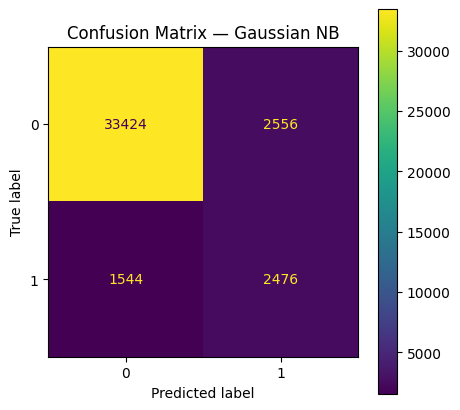

              precision    recall  f1-score   support

           0     0.9558    0.9290    0.9422     35980
           1     0.4921    0.6159    0.5471      4020

    accuracy                         0.8975     40000
   macro avg     0.7239    0.7724    0.7446     40000
weighted avg     0.9092    0.8975    0.9025     40000



In [26]:
champion_pred = (champion_prob >= best_threshold).astype(int)

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, champion_pred, cmap=None, ax=ax)
ax.set_title(f'Confusion Matrix — {champion_name}')
plt.show()

print(classification_report(y_test, champion_pred, digits=4))

## 20. Probability calibration

Discrimination and calibration are different. ROC-AUC may be high even when predicted probabilities do not correspond closely to observed event frequencies. The reliability curve and Brier score provide a first calibration diagnostic. If probabilities will drive expected-value calculations, post-hoc calibration (Platt scaling or isotonic regression) should be validated before deployment.

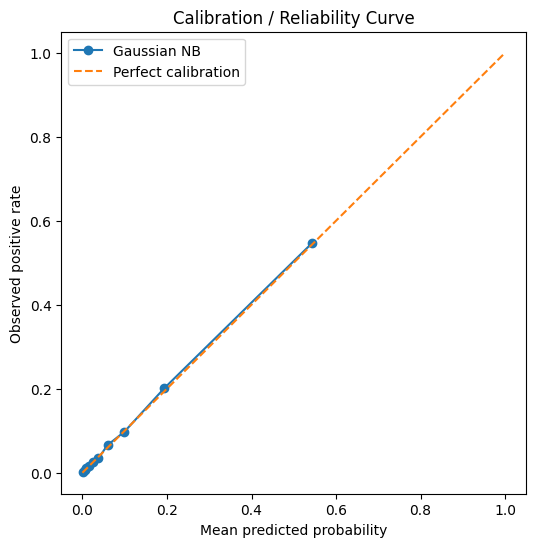

Brier score: 0.060959


In [27]:
prob_true, prob_pred = calibration_curve(y_test, champion_prob, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(prob_pred, prob_true, marker='o', label=champion_name)
ax.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed positive rate')
ax.set_title('Calibration / Reliability Curve')
ax.legend()
plt.show()

print('Brier score:', round(brier_score_loss(y_test, champion_prob), 6))

## 21. Lift / gains analysis

Ranking models are often operationalized by contacting only the highest-scoring customers. Lift asks whether the top-scored fraction contains more positives than random selection. This can be more actionable than a single classification threshold when the bank has a fixed campaign capacity.

In [28]:
scored = pd.DataFrame({'y': y_test.to_numpy(), 'prob': champion_prob})
scored = scored.sort_values('prob', ascending=False).reset_index(drop=True)
scored['bucket'] = pd.qcut(scored.index, q=10, labels=False, duplicates='drop') + 1

lift = scored.groupby('bucket').agg(
    customers=('y','size'),
    positives=('y','sum'),
    response_rate=('y','mean'),
    mean_score=('prob','mean')
).reset_index()
lift['lift_vs_average'] = lift['response_rate'] / y_test.mean()
lift['cumulative_positives'] = lift['positives'].cumsum()
lift['cumulative_recall'] = lift['cumulative_positives'] / lift['positives'].sum()
lift

,bucket,customers,positives,response_rate,mean_score,lift_vs_average,cumulative_positives,cumulative_recall
0,1,4000,2186,0.5465,0.5430,5.4378,2186,0.5438
1,2,4000,803,0.2008,0.1932,1.9975,2989,0.7435
2,3,4000,391,0.0978,0.0995,0.9726,3380,0.8408
3,4,4000,263,0.0658,0.0594,0.6542,3643,0.9062
4,5,4000,137,0.0343,0.0377,0.3408,3780,0.9403
5,6,4000,104,0.0260,0.0243,0.2587,3884,0.9662
6,7,4000,62,0.0155,0.0155,0.1542,3946,0.9816
7,8,4000,42,0.0105,0.0096,0.1045,3988,0.9920
8,9,4000,24,0.0060,0.0054,0.0597,4012,0.9980
9,10,4000,8,0.0020,0.0021,0.0199,4020,1.0000


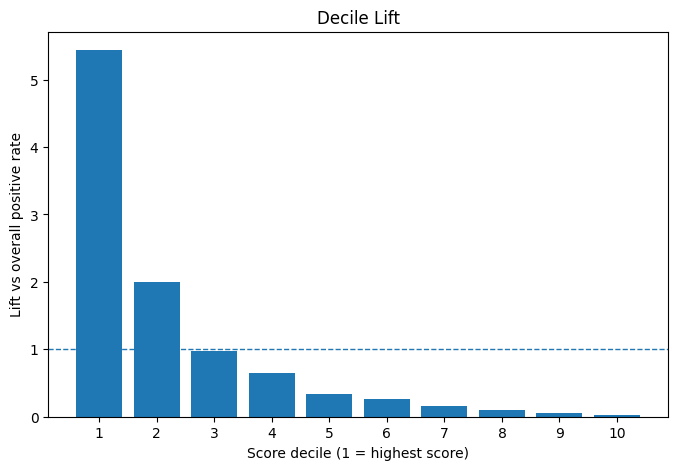

In [29]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(lift['bucket'].astype(str), lift['lift_vs_average'])
ax.axhline(1.0, linestyle='--', linewidth=1)
ax.set_xlabel('Score decile (1 = highest score)')
ax.set_ylabel('Lift vs overall positive rate')
ax.set_title('Decile Lift')
plt.show()

## 22. Model explainability with permutation importance

Permutation importance measures the decrease in model performance when one feature is randomly shuffled. It is model-agnostic and therefore works for the final champion even when the estimator does not expose native feature importances.

Because it repeatedly re-scores the model, it is estimated on a reproducible subset of the test set. Importance describes predictive dependence, **not causality**.

,feature,importance_mean,importance_std
53,var_53,0.0088,0.0016
110,var_110,0.0066,0.0003
12,var_12,0.0063,0.0001
146,var_146,0.0060,0.0001
165,var_165,0.0059,0.0022
6,var_6,0.0057,0.0005
80,var_80,0.0056,0.0012
170,var_170,0.0056,0.0012
166,var_166,0.0052,0.0001
115,var_115,0.0052,0.0010


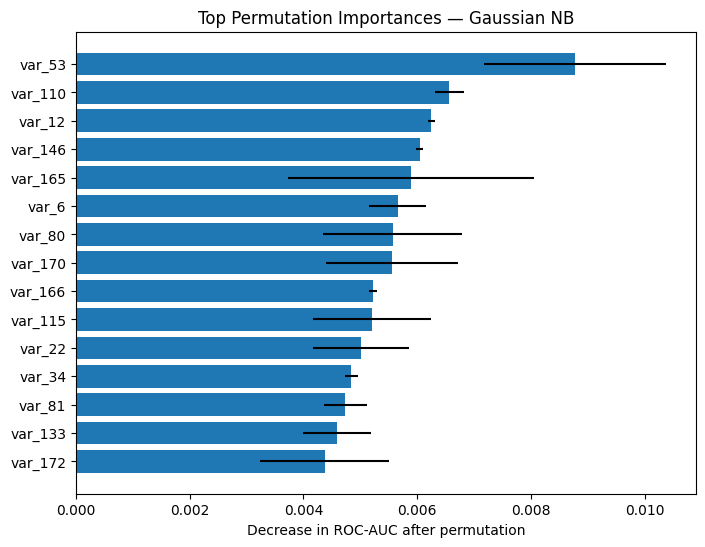

In [30]:
perm_n = min(PERMUTATION_SAMPLE, len(X_test))
X_perm, _, y_perm, _ = train_test_split(
    X_test, y_test, train_size=perm_n,
    random_state=RANDOM_STATE, stratify=y_test
)

perm = permutation_importance(
    champion_model, X_perm, y_perm,
    scoring='roc_auc', n_repeats=2,
    random_state=RANDOM_STATE, n_jobs=1
)

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(importance.head(20))

fig, ax = plt.subplots(figsize=(8,6))
top_imp = importance.head(15).sort_values('importance_mean')
ax.barh(top_imp['feature'], top_imp['importance_mean'], xerr=top_imp['importance_std'])
ax.set_xlabel('Decrease in ROC-AUC after permutation')
ax.set_title(f'Top Permutation Importances — {champion_name}')
plt.show()

## 23. Error analysis

Even without semantic feature definitions, we can compare model confidence for true positives, false positives, true negatives and false negatives. This helps identify whether errors are concentrated near the threshold or occur even at high confidence.

In [31]:
error_df = pd.DataFrame({
    'ID_code': id_test.to_numpy(),
    'actual': y_test.to_numpy(),
    'probability': champion_prob,
    'predicted': champion_pred
})

error_df['outcome'] = np.select(
    [
        (error_df.actual==1) & (error_df.predicted==1),
        (error_df.actual==0) & (error_df.predicted==1),
        (error_df.actual==0) & (error_df.predicted==0),
        (error_df.actual==1) & (error_df.predicted==0),
    ],
    ['TP','FP','TN','FN'], default='Other'
)

error_summary = error_df.groupby('outcome').agg(
    count=('actual','size'),
    mean_probability=('probability','mean'),
    median_probability=('probability','median'),
    min_probability=('probability','min'),
    max_probability=('probability','max')
).sort_index()
error_summary

,count,mean_probability,median_probability,min_probability,max_probability
outcome,,,,,
FN,1544,0.1011,0.0920,0.0008,0.2256
FP,2556,0.3976,0.3486,0.2264,0.9627
TN,33424,0.0410,0.0213,0.0000,0.2259
TP,2476,0.5723,0.5580,0.2259,0.9982


## 24. Production recommendation

The production candidate should not be selected from one metric in isolation. Recommended decision criteria:
- Strong and stable ROC-AUC / PR-AUC.
- Acceptable recall/precision at an economically justified threshold.
- Reasonable probability calibration if probabilities are consumed directly.
- Stable cross-validation results.
- Operationally acceptable training/inference complexity.
- Reproducible preprocessing and artifact versioning.

The next cell creates a data-driven summary from this notebook's actual results.

In [32]:
champion_metrics = metric_row(champion_name, y_test, champion_prob, best_threshold)

print('PRODUCTION CANDIDATE SUMMARY')
print('='*60)
print(f'Champion model          : {champion_name}')
print(f'Hold-out ROC-AUC        : {champion_metrics["ROC_AUC"]:.4f}')
print(f'Hold-out PR-AUC         : {champion_metrics["PR_AUC"]:.4f}')
print(f'Analytical threshold    : {best_threshold:.4f}')
print(f'Precision @ threshold   : {champion_metrics["Precision"]:.4f}')
print(f'Recall @ threshold      : {champion_metrics["Recall"]:.4f}')
print(f'F1 @ threshold          : {champion_metrics["F1"]:.4f}')
print(f'Balanced accuracy       : {champion_metrics["Balanced_Accuracy"]:.4f}')
print(f'MCC                     : {champion_metrics["MCC"]:.4f}')
print(f'Brier score             : {champion_metrics["Brier"]:.4f}')
print('\nRecommendation: use this model as the current champion, subject to business')
print('threshold selection, calibration validation, temporal/out-of-time validation,')
print('monitoring, and governance checks before live deployment.')

PRODUCTION CANDIDATE SUMMARY
Champion model          : Gaussian NB
Hold-out ROC-AUC        : 0.8882
Hold-out PR-AUC         : 0.5769
Analytical threshold    : 0.2259
Precision @ threshold   : 0.4921
Recall @ threshold      : 0.6159
F1 @ threshold          : 0.5471
Balanced accuracy       : 0.7724
MCC                     : 0.4940
Brier score             : 0.0610

Recommendation: use this model as the current champion, subject to business
threshold selection, calibration validation, temporal/out-of-time validation,
monitoring, and governance checks before live deployment.


## 25. Challenges faced and techniques used

### Challenge 1 — Anonymized predictors
**Problem:** Feature names provide no semantic context, so business interpretation, domain outlier rules, and domain-driven feature engineering are not possible.

**Technique:** Use statistically defensible analysis: distribution comparison, standardized mean differences, missingness/uniqueness checks, correlation, univariate ROC-AUC, mutual information, model-based permutation importance, and error analysis. Do not assign invented meanings to variables.

### Challenge 2 — Class imbalance
**Problem:** Positive cases are substantially less common than negatives. Accuracy can therefore reward majority-class predictions.

**Technique:** Use stratified splitting/CV, class weighting where supported, ROC-AUC and PR-AUC, precision/recall/F1, balanced accuracy and MCC. Analyze the classification threshold separately from the probability model.

### Challenge 3 — Many continuous predictors
**Problem:** 200 features create opportunities for redundancy, weak signal and overfitting.

**Technique:** Audit variance/correlation, measure univariate and non-linear signal, regularize linear models, constrain tree complexity, use cross-validation, early stopping and hyperparameter tuning.

### Challenge 4 — Outliers without domain definitions
**Problem:** It is impossible to know whether extreme values are errors or real behavior.

**Technique:** Quantify IQR extremes but avoid arbitrary deletion. Prefer robust/non-linear learners and only remove observations when a defensible data-quality rule exists.

### Challenge 5 — Model selection under imbalance
**Problem:** Different metrics favor different behavior and a threshold of 0.50 is not automatically optimal.

**Technique:** Rank probability models mainly by ROC-AUC/PR-AUC, inspect calibration and lift, then choose a threshold based on explicit business costs/capacity. F1 optimization is demonstrated as an analytical example.

### Challenge 6 — Generalization and production readiness
**Problem:** A random split cannot prove future temporal stability, and anonymization prevents direct drift interpretation.

**Technique:** Use stratified CV plus an untouched hold-out. For production, add out-of-time validation when timestamps become available, monitor feature distributions and score distributions, monitor realized performance, and retrain under governed triggers.

## 26. Limitations and recommended next experiments

1. **No feature semantics:** causal or business interpretation is not supported by the supplied dataset.
2. **No timestamp:** true out-of-time validation and temporal drift analysis cannot be performed.
3. **No economic cost matrix:** the final operational threshold cannot be determined optimally from model metrics alone.
4. **No external population:** transportability to a different customer population is untested.
5. **Calibration:** if predicted probabilities are used as actual propensities, compare Platt/isotonic calibration on a dedicated validation design.
6. **Advanced boosting:** if the deployment environment supports them, compare optimized LightGBM/XGBoost/CatBoost with the same leakage-safe validation design.
7. **Feature selection:** test whether a smaller top-signal subset preserves performance and improves maintainability.
8. **Drift monitoring:** production should monitor PSI/KS-style feature and score drift plus outcome-based metrics when labels arrive.

## 27. Save the model artifact and inference metadata

The pipeline contains preprocessing plus the estimator, so inference does not require manually repeating transformations. We also save feature order, threshold, metrics and model name as metadata.

In [33]:
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'customer_transaction_champion.joblib'
metadata_path = artifacts_dir / 'customer_transaction_metadata.json'

joblib.dump(champion_model, model_path)
metadata = {
    'model_name': champion_name,
    'feature_columns': feature_cols,
    'decision_threshold': best_threshold,
    'test_roc_auc': champion_metrics['ROC_AUC'],
    'test_pr_auc': champion_metrics['PR_AUC'],
    'test_precision': champion_metrics['Precision'],
    'test_recall': champion_metrics['Recall'],
    'test_f1': champion_metrics['F1'],
    'random_state': RANDOM_STATE,
}
metadata_path.write_text(json.dumps(metadata, indent=2))

print('Saved model   :', model_path.resolve())
print('Saved metadata:', metadata_path.resolve())

Saved model   : C:\Users\mathew\CustPred\artifacts\customer_transaction_champion.joblib
Saved metadata: C:\Users\mathew\CustPred\artifacts\customer_transaction_metadata.json


## 28. Reusable inference example

The example below demonstrates how a future batch can be scored while preserving `ID_code` for traceability. New data must contain the same 200 predictor columns in the training schema.

In [34]:
# Example: score a few held-out customers using the saved pipeline.
loaded_model = joblib.load(model_path)

example_new_data = X_test.head(5).copy()
example_ids = id_test.head(5).reset_index(drop=True)
example_prob = get_positive_probability(loaded_model, example_new_data)

predictions = pd.DataFrame({
    'ID_code': example_ids,
    'transaction_probability': example_prob,
    'predicted_transaction': (example_prob >= best_threshold).astype(int)
})
predictions

,ID_code,transaction_probability,predicted_transaction
0,train_199837,0.0025,0
1,train_149409,0.1044,0
2,train_43642,0.0032,0
3,train_157332,0.0089,0
4,train_189470,0.0239,0


# Final conclusion

This notebook delivers a complete machine-learning workflow for customer transaction prediction: data-quality analysis, statistically appropriate EDA for anonymized variables, imbalance-aware validation, multiple algorithm families, model comparison, cross-validation, hyperparameter tuning, threshold analysis, calibration, lift, explainability, error analysis, artifact persistence, and production recommendations.

The final champion is selected from measured notebook results rather than assumed in advance. Before live banking use, the model should additionally pass business-cost thresholding, out-of-time validation, calibration review, fairness/compliance assessment appropriate to the actual underlying features, monitoring design, and model-governance approval.